In [72]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import plotly.express as px

In [74]:
df = pd.read_csv(
    "../data/processed/feature_matrix_geo_v2.csv"
)

print(df.shape)

df.head()

(4964, 13)


,lat,lon,mean_annual_rf,std_annual,cv,dry_days,heavy_days,elevation,soil_clay,soil_soc,slope,water_occurrence,water_norm
0,8.25,77.00,1368.70980,409.68338,0.299321,253.051282,0.487179,0.0,0,NaN,127.199997,100.0,1.00
1,8.25,77.25,1163.10000,317.94876,0.273363,265.871795,0.487179,80.0,346,NaN,120.199997,0.0,0.00
2,8.25,77.50,749.88873,343.41086,0.457949,313.076923,0.282051,71.0,346,NaN,134.000000,12.0,0.12
3,8.25,77.75,758.49920,328.97153,0.433714,294.102564,0.256410,24.0,330,NaN,75.000000,0.0,0.00
4,8.50,76.75,1833.17690,363.57733,0.198332,233.205128,0.820513,0.0,0,NaN,28.400000,100.0,1.00


In [75]:
df = df.replace(
    [-9999, -32768],
    np.nan
)

df = df.dropna()

print(df.shape)

(4473, 13)


In [76]:
df["lat_lon_interaction"] = (
    df["lat"] *
    df["lon"]
)

df["elev_x_soc"] = (
    df["elevation"] *
    df["soil_soc"]
)

df["clay_soc_ratio"] = (
    df["soil_clay"] /
    (
        df["soil_soc"] + 1e-6
    )
)

In [77]:
features = [

    "lat",
    "lon",

    "elevation",
    "soil_clay",
    "soil_soc",
    "slope",

    "lat_lon_interaction",
    "elev_x_soc",
    "clay_soc_ratio"

]
target = "mean_annual_rf"

In [78]:
X = df[features]

y = df[target]

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

In [79]:
rf = RandomForestRegressor(

    n_estimators=500,

    max_depth=20,

    min_samples_leaf=3,

    n_jobs=-1,

    random_state=42

)

rf.fit(
    X_train,
    y_train
)

RandomForestRegressor(max_depth=20, min_samples_leaf=3, n_estimators=500,
                      n_jobs=-1, random_state=42)

In [80]:
pred = rf.predict(
    X_test
)

In [81]:
validation = pd.DataFrame({
    "observed": y_test,
    "predicted": pred
})

validation.to_csv(
    "../data/processed/downscaling_validation.csv",
    index=False
)

In [82]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

mae = mean_absolute_error(
    y_test,
    pred
)

r2 = r2_score(
    y_test,
    pred
)

print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)

RMSE : 256.13448529180175
MAE  : 112.63753198416563
R²   : 0.8669510117190353


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    pred,
    alpha=0.5
)

mn = min(y_test.min(), pred.min())
mx = max(y_test.max(), pred.max())

plt.plot(
    [mn,mx],
    [mn,mx],
    "r--"
)

plt.xlabel("Observed Rainfall")
plt.ylabel("Predicted Rainfall")

plt.title(
    f"RF Downscaling Validation\nR²={r2:.3f}"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/downscaling_validation.png",
    dpi=300
)

plt.show()

In [83]:
importance = pd.DataFrame({

    "feature": features,

    "importance":
    rf.feature_importances_

})

importance = importance.sort_values(

    "importance",
    ascending=False

)

importance

,feature,importance
1,lon,0.579459
6,lat_lon_interaction,0.134578
0,lat,0.105637
4,soil_soc,0.068639
2,elevation,0.035064
7,elev_x_soc,0.024707
8,clay_soc_ratio,0.019132
5,slope,0.016992
3,soil_clay,0.015792


In [84]:
df["downscaled_rf"] = rf.predict(
    df[features]
)

In [85]:
df.to_csv(

    "../data/processed/downscaled_rainfall.csv",

    index=False

)

In [97]:
fig = px.scatter_map(

    df,

    lat="lat",

    lon="lon",

    color="downscaled_rf",

    zoom=4,

    height=700,

    title="Downscaled Rainfall Surface"

)
plt.savefig('../outputs/figures/downscaled_images.png')
fig.show()

<Figure size 640x480 with 0 Axes>

DOWNSCALING


In [87]:
import numpy as np
import pandas as pd

In [88]:
lats = np.arange(df.lat.min(), df.lat.max(), 0.1)
lons = np.arange(df.lon.min(), df.lon.max(), 0.1)

In [89]:
fine_grid = pd.DataFrame(

    [
        (lat, lon)

        for lat in lats
        for lon in lons
    ],

    columns=[
        "lat",
        "lon"
    ]
)

print(fine_grid.shape)

(65339, 2)


In [90]:
from scipy.spatial import cKDTree
source = df[
    [
        "lat",
        "lon"
    ]
].values

tree = cKDTree(source)
target = fine_grid[
    [
        "lat",
        "lon"
    ]
].values

geo_cols = [

    "elevation",
    "soil_clay",
    "soil_soc",
    "slope"

]

dist, idx = tree.query(target, k=4)

for col in geo_cols:

    vals = df[col].values[idx]

    weights = 1/(dist + 1e-6)

    fine_grid[col] = (
        (vals * weights).sum(axis=1)
        /
        weights.sum(axis=1)
    )

In [91]:

fine_grid[
    "lat_lon_interaction"
] = (

    fine_grid["lat"]
    *
    fine_grid["lon"]

)
fine_grid[
    "elev_x_soc"
] = (

    fine_grid["elevation"]
    *
    fine_grid["soil_soc"]

)
fine_grid[
    "clay_soc_ratio"
] = (

    fine_grid["soil_clay"]

    /

    (
        fine_grid["soil_soc"]
        +
        1e-6
    )

)

In [92]:
fine_grid[
    "downscaled_rf"
] = rf.predict(

    fine_grid[
        features
    ]

)

In [93]:
fine_grid.to_csv(

    "../data/processed/downscaled_rainfall_5km.csv",

    index=False

)

In [59]:
import plotly.graph_objects as go
grid = fine_grid.pivot(
    index="lat",
    columns="lon",
    values="downscaled_rf"
)
fig = go.Figure(

    data=go.Heatmap(

        z=grid.values,

        x=grid.columns,

        y=grid.index

    )

)

fig.update_layout(
    title="Downscaled Rainfall Surface"
)

fig.show()

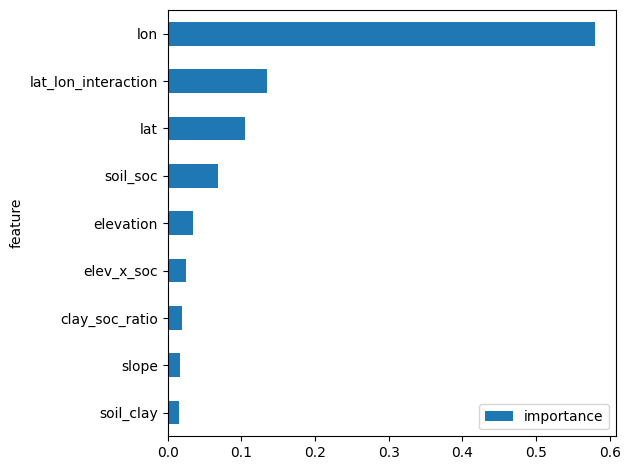

In [64]:
importance.sort_values(
    "importance"
).plot.barh(
    x="feature",
    y="importance"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/downscaling_feature_importance.png",
    dpi=300
)

In [60]:
import plotly.express as px

fig = go.Figure(

    data=go.Heatmap(

        z=grid.values,

        x=grid.columns,

        y=grid.index

    )

)

fig.update_layout(
    title="Downscaled Rainfall Surface"
)

fig.show()

fig.show()

In [61]:
fig = px.density_map(

    fine_grid,

    lat="lat",
    lon="lon",

    z="downscaled_rf",

    radius=10,

    zoom=4,

    height=800,

    title="Downscaled Rainfall Surface (RF Model)"

)

fig.show()

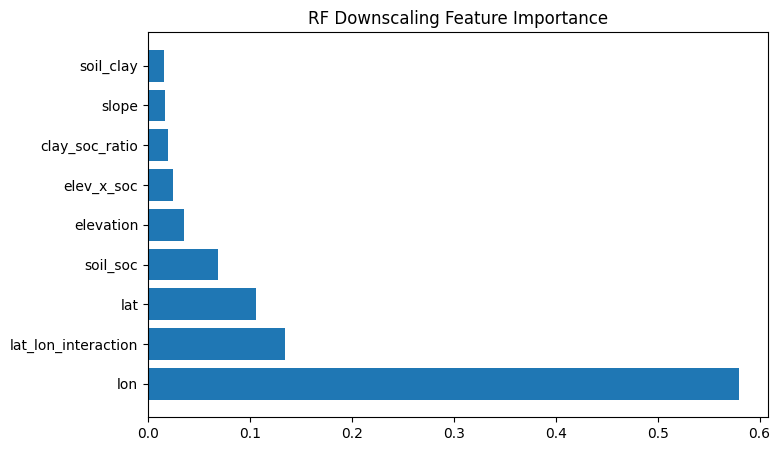

In [62]:
importance = pd.DataFrame({

    "feature": features,

    "importance":
    rf.feature_importances_

})

importance = importance.sort_values(
    "importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.title(
    "RF Downscaling Feature Importance"
)

plt.show()

In [42]:
fig = px.scatter_map(

    df.sample(
        3000,
        random_state=42
    ),

    lat="lat",
    lon="lon",

    color="mean_annual_rf",

    zoom=4,

    title="Original IMD Rainfall Grid"
)

fig.show()

In [ ]:
fig = px.scatter_map(

    fine_grid.sample(
        10000,
        random_state=42
    ),

    lat="lat",
    lon="lon",

    color="downscaled_rf",

    zoom=4,

    title="Downscaled Rainfall Grid"
)

fig.show()

In [44]:
importance.sort_values(
    "importance",
    ascending=False
)

,feature,importance
1,lon,0.579459
6,lat_lon_interaction,0.134578
0,lat,0.105637
4,soil_soc,0.068639
2,elevation,0.035064
7,elev_x_soc,0.024707
8,clay_soc_ratio,0.019132
5,slope,0.016992
3,soil_clay,0.015792


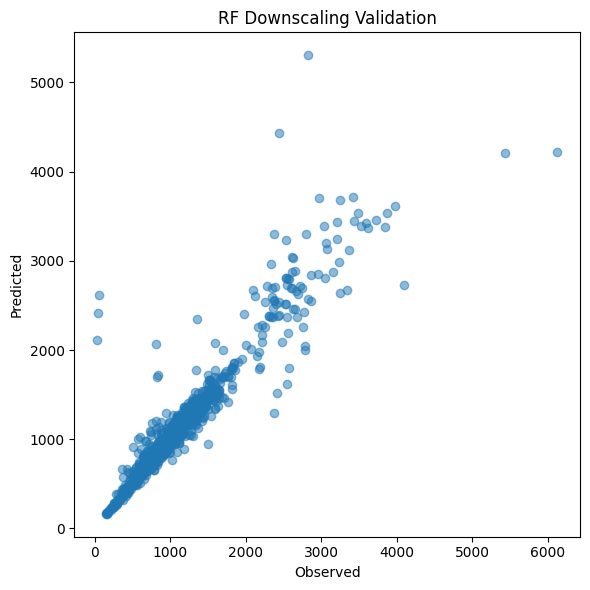

In [67]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    pred,
    alpha=0.5
)

plt.xlabel(
    "Observed"
)

plt.ylabel(
    "Predicted"
)

plt.title(
    "RF Downscaling Validation"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/06_downscaling_validation.png"
)

plt.show()

In [69]:
importance = pd.DataFrame({

"feature":[
"lon",
"lat_lon_interaction",
"lat",
"soil_soc",
"elevation",
"elev_x_soc",
"clay_soc_ratio",
"slope",
"soil_clay"
],

"importance":[
0.579,
0.135,
0.106,
0.069,
0.035,
0.025,
0.019,
0.017,
0.016
]

})

In [71]:
print([v for v in dir() if "model" in v.lower()])

[]


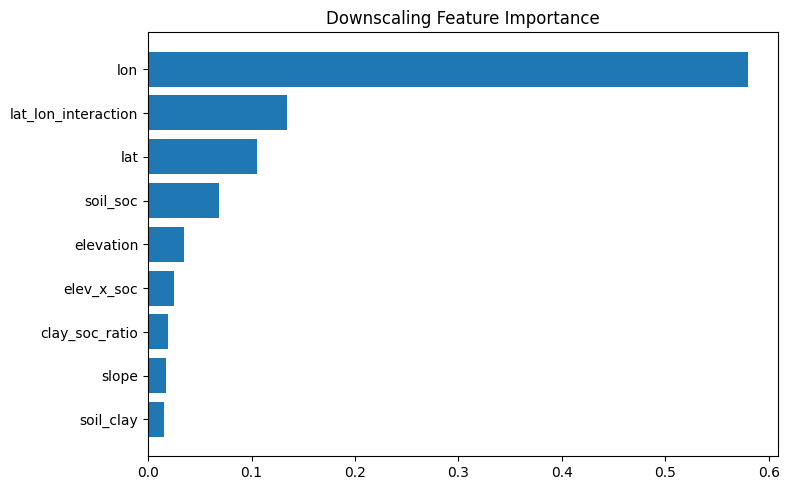

In [95]:
importance = pd.DataFrame({

    "feature": X.columns,

    "importance":
    rf.feature_importances_

})

importance = importance.sort_values(
    "importance"
)

plt.figure(figsize=(8,5))

plt.barh(

    importance["feature"],

    importance["importance"]

)

plt.title(
    "Downscaling Feature Importance"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/07_downscaling_feature_importance.png"
)

plt.show()